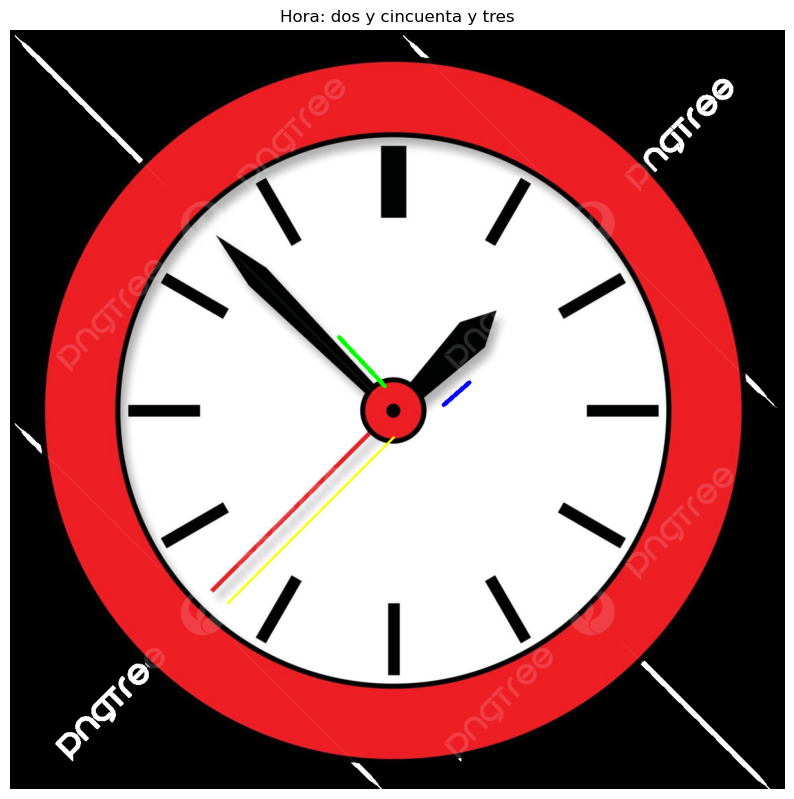

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

nombres_hora = {
    0: "doce", 1: "una", 2: "dos", 3: "tres", 4: "cuatro", 5: "cinco",
    6: "seis", 7: "siete", 8: "ocho", 9: "nueve", 10: "diez", 11: "once",
    12: "doce"
}

nombres_minuto = {
    0: "en punto", 1: "uno", 2: "dos", 3: "tres", 4: "cuatro", 5: "cinco",
    6: "seis", 7: "siete", 8: "ocho", 9: "nueve", 10: "diez", 11: "once",
    12: "doce", 13: "trece", 14: "catorce", 15: "quince", 16: "dieciséis",
    17: "diecisiete", 18: "dieciocho", 19: "diecinueve", 20: "veinte",
    21: "veintiuno", 22: "veintidós", 23: "veintitrés", 24: "veinticuatro",
    25: "veinticinco", 26: "veintiséis", 27: "veintisiete", 28: "veintiocho",
    29: "veintinueve", 30: "treinta", 31: "treinta y uno", 32: "treinta y dos",
    33: "treinta y tres", 34: "treinta y cuatro", 35: "treinta y cinco",
    36: "treinta y seis", 37: "treinta y siete", 38: "treinta y ocho",
    39: "treinta y nueve", 40: "cuarenta", 41: "cuarenta y uno",
    42: "cuarenta y dos", 43: "cuarenta y tres", 44: "cuarenta y cuatro",
    45: "cuarenta y cinco", 46: "cuarenta y seis", 47: "cuarenta y siete",
    48: "cuarenta y ocho", 49: "cuarenta y nueve", 50: "cincuenta",
    51: "cincuenta y uno", 52: "cincuenta y dos", 53: "cincuenta y tres",
    54: "cincuenta y cuatro", 55: "cincuenta y cinco", 56: "cincuenta y seis",
    57: "cincuenta y siete", 58: "cincuenta y ocho", 59: "cincuenta y nueve"
}

imagen_bgr = cv2.imread('reloj.jpg')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)
bordes = cv2.Canny(gris, 50, 150)

lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=50, minLineLength=40, maxLineGap=10)
centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2

def calcular_angulo(x1, y1, x2, y2):
    dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
    dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    angulo = np.degrees(np.arctan2(dy, dx))
    angulo = (90 - angulo) % 360
    return angulo

manecillas = []
if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        longitud = np.hypot(x2 - x1, y2 - y1)
        distancia_centro = min(np.hypot(x1 - centro_x, y1 - centro_y), np.hypot(x2 - centro_x, y2 - centro_y))
        if distancia_centro < 100 and longitud > 50:
            angulo = calcular_angulo(x1, y1, x2, y2)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo
            })

if len(manecillas) >= 3:
    manecillas.sort(key=lambda x: x['longitud'])
    horero = manecillas[0]
    minutero = manecillas[len(manecillas)//2]
    segundero = manecillas[-1]

    hora = int((horero['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)
    segundos = int((segundero['angulo'] / 6) % 60)

    fraccion_hora = (horero['angulo'] / 30) % 12
    if abs(fraccion_hora - hora) > 0.5:
        hora = (hora + 1) % 12

    hora_texto = nombres_hora[hora]
    minuto_texto = nombres_minuto[minutos]
    titulo = f"{hora_texto} y {minuto_texto}"

    imagen_resultado = imagen_rgb.copy()
    cv2.line(imagen_resultado, (horero['puntos'][0], horero['puntos'][1]), (horero['puntos'][2], horero['puntos'][3]), (0, 0, 255), 5)
    cv2.line(imagen_resultado, (minutero['puntos'][0], minutero['puntos'][1]), (minutero['puntos'][2], minutero['puntos'][3]), (0, 255, 0), 5)
    cv2.line(imagen_resultado, (segundero['puntos'][0], segundero['puntos'][1]), (segundero['puntos'][2], segundero['puntos'][3]), (255, 255, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_resultado)
    plt.title(f'Hora: {titulo}')
    plt.axis('off')
    plt.show()

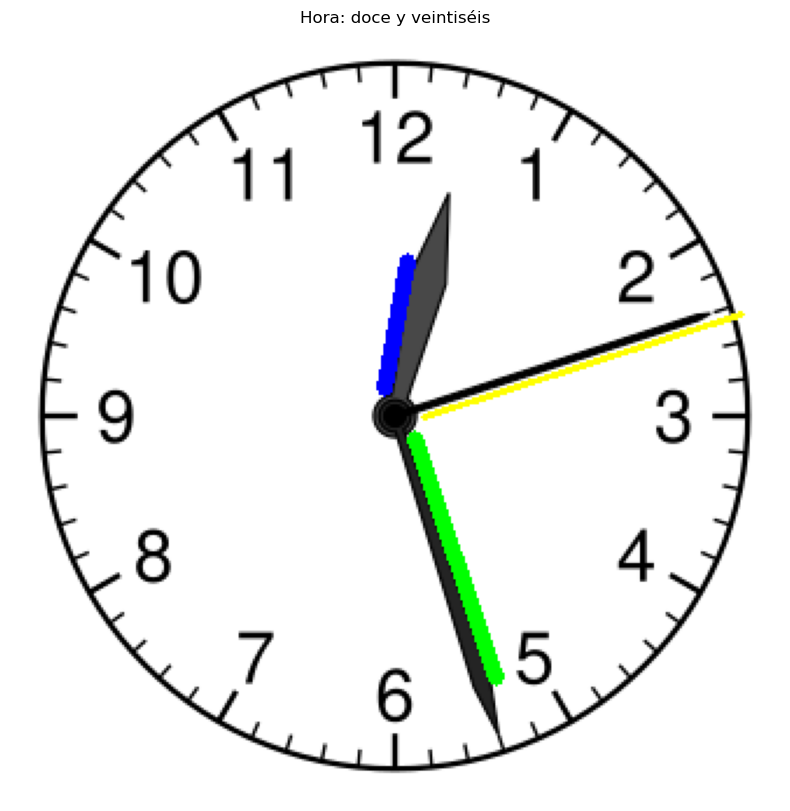

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

nombres_hora = {
    0: "doce", 1: "una", 2: "dos", 3: "tres", 4: "cuatro", 5: "cinco",
    6: "seis", 7: "siete", 8: "ocho", 9: "nueve", 10: "diez", 11: "once",
    12: "doce"
}

nombres_minuto = {
    0: "en punto", 1: "uno", 2: "dos", 3: "tres", 4: "cuatro", 5: "cinco",
    6: "seis", 7: "siete", 8: "ocho", 9: "nueve", 10: "diez", 11: "once",
    12: "doce", 13: "trece", 14: "catorce", 15: "quince", 16: "dieciséis",
    17: "diecisiete", 18: "dieciocho", 19: "diecinueve", 20: "veinte",
    21: "veintiuno", 22: "veintidós", 23: "veintitrés", 24: "veinticuatro",
    25: "veinticinco", 26: "veintiséis", 27: "veintisiete", 28: "veintiocho",
    29: "veintinueve", 30: "treinta", 31: "treinta y uno", 32: "treinta y dos",
    33: "treinta y tres", 34: "treinta y cuatro", 35: "treinta y cinco",
    36: "treinta y seis", 37: "treinta y siete", 38: "treinta y ocho",
    39: "treinta y nueve", 40: "cuarenta", 41: "cuarenta y uno",
    42: "cuarenta y dos", 43: "cuarenta y tres", 44: "cuarenta y cuatro",
    45: "cuarenta y cinco", 46: "cuarenta y seis", 47: "cuarenta y siete",
    48: "cuarenta y ocho", 49: "cuarenta y nueve", 50: "cincuenta",
    51: "cincuenta y uno", 52: "cincuenta y dos", 53: "cincuenta y tres",
    54: "cincuenta y cuatro", 55: "cincuenta y cinco", 56: "cincuenta y seis",
    57: "cincuenta y siete", 58: "cincuenta y ocho", 59: "cincuenta y nueve"
}

imagen_bgr = cv2.imread('reloj2.png')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)
bordes = cv2.Canny(gris, 50, 150)

lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=50, minLineLength=40, maxLineGap=10)
centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2

def calcular_angulo(x1, y1, x2, y2):
    dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
    dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    angulo = np.degrees(np.arctan2(dy, dx))
    angulo = (90 - angulo) % 360
    return angulo

manecillas = []
if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        longitud = np.hypot(x2 - x1, y2 - y1)
        distancia_centro = min(np.hypot(x1 - centro_x, y1 - centro_y), np.hypot(x2 - centro_x, y2 - centro_y))
        if distancia_centro < 100 and longitud > 50:
            angulo = calcular_angulo(x1, y1, x2, y2)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo
            })

if len(manecillas) >= 3:
    manecillas.sort(key=lambda x: x['longitud'])
    horero = manecillas[0]
    minutero = manecillas[len(manecillas)//2]
    segundero = manecillas[-1]

    hora = int((horero['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)
    segundos = int((segundero['angulo'] / 6) % 60)

    fraccion_hora = (horero['angulo'] / 30) % 12
    if abs(fraccion_hora - hora) > 0.5:
        hora = (hora + 1) % 12

    hora_texto = nombres_hora[hora]
    minuto_texto = nombres_minuto[minutos]
    titulo = f"{hora_texto} y {minuto_texto}"

    imagen_resultado = imagen_rgb.copy()
    cv2.line(imagen_resultado, (horero['puntos'][0], horero['puntos'][1]), (horero['puntos'][2], horero['puntos'][3]), (0, 0, 255), 5)
    cv2.line(imagen_resultado, (minutero['puntos'][0], minutero['puntos'][1]), (minutero['puntos'][2], minutero['puntos'][3]), (0, 255, 0), 5)
    cv2.line(imagen_resultado, (segundero['puntos'][0], segundero['puntos'][1]), (segundero['puntos'][2], segundero['puntos'][3]), (255, 255, 0), 2)

    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_resultado)
    plt.title(f'Hora: {titulo}')
    plt.axis('off')
    plt.show()